Files found: ['Covid-19/covid_19_clean_complete.csv', 'Covid-19/day_wise.csv', 'sample_data/mnist_train_small.csv', 'sample_data/mnist_test.csv', 'sample_data/california_housing_train.csv', 'sample_data/california_housing_test.csv']
Using file: Covid-19/covid_19_clean_complete.csv
  Province/State Country/Region       Lat       Long        Date  Confirmed  \
0            NaN    Afghanistan  33.93911  67.709953  2020-01-22          0   
1            NaN        Albania  41.15330  20.168300  2020-01-22          0   
2            NaN        Algeria  28.03390   1.659600  2020-01-22          0   
3            NaN        Andorra  42.50630   1.521800  2020-01-22          0   
4            NaN         Angola -11.20270  17.873900  2020-01-22          0   

   Deaths  Recovered  Active             WHO Region  
0       0          0       0  Eastern Mediterranean  
1       0          0       0                 Europe  
2       0          0       0                 Africa  
3       0          0       

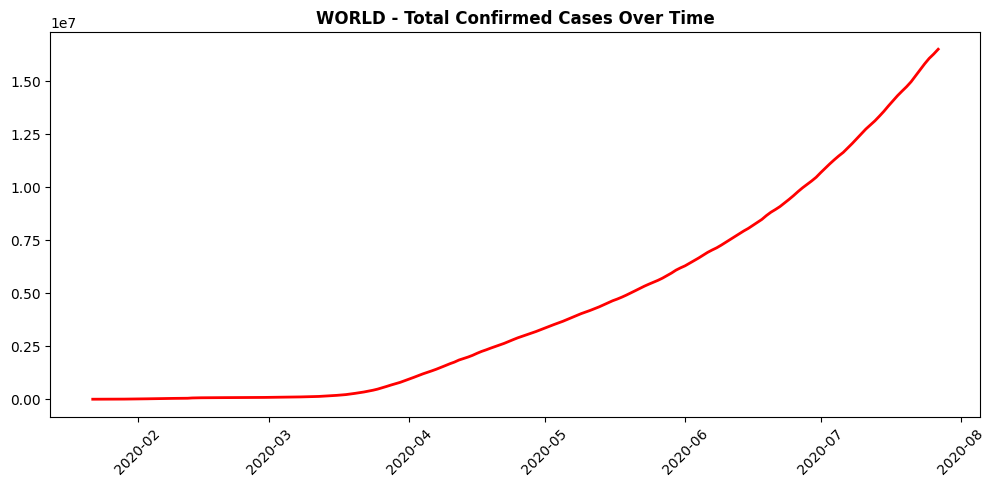

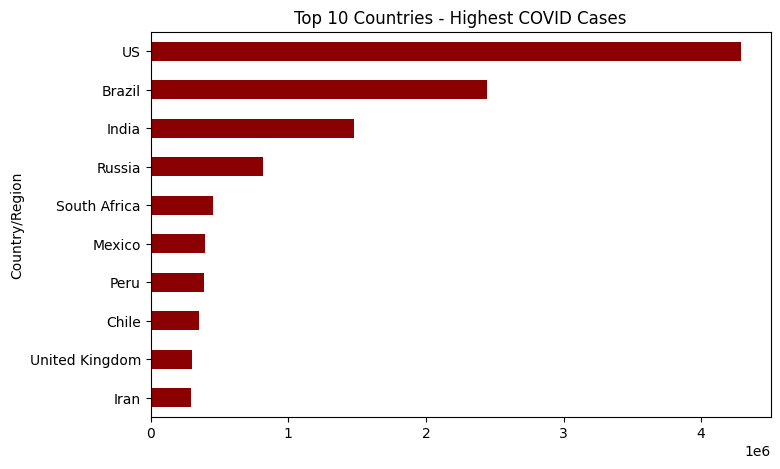

<Figure size 800x500 with 0 Axes>

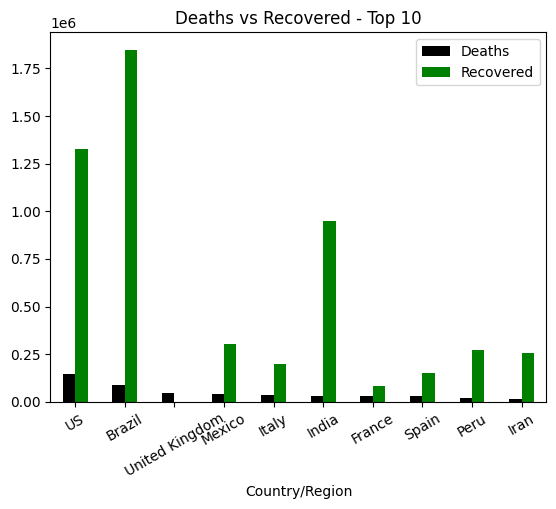

Project 3 DONE DHEE! 🎉


In [2]:
import zipfile, os, glob
import pandas as pd
import matplotlib.pyplot as plt

# Unzip again
with zipfile.ZipFile('archive (5).zip', 'r') as zip_ref:
    zip_ref.extractall('.')

# File enge irukku nu thedurom
all_csv = glob.glob('**/*.csv', recursive=True)
print("Files found:", all_csv)

# Correct file path edukkrom
csv_file = [f for f in all_csv if 'covid_19_clean_complete' in f][0]
print("Using file:", csv_file)

df = pd.read_csv(csv_file)
print(df.head())
print("Rows:", df.shape)

df['Date'] = pd.to_datetime(df['Date'])

# Graph 1: World total cases
daily = df.groupby('Date')['Confirmed'].sum().reset_index()
plt.figure(figsize=(12,5))
plt.plot(daily['Date'], daily['Confirmed'], color='red', linewidth=2)
plt.title('WORLD - Total Confirmed Cases Over Time', weight='bold')
plt.xticks(rotation=45)
plt.show()

# Graph 2: Top 10 Countries
latest = df[df['Date'] == df['Date'].max()]
top10 = latest.groupby('Country/Region')['Confirmed'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5))
top10.plot(kind='barh', color='darkred')
plt.title('Top 10 Countries - Highest COVID Cases')
plt.gca().invert_yaxis()
plt.show()

# Graph 3: Deaths vs Recovered
plt.figure(figsize=(8,5))
latest.groupby('Country/Region')[['Deaths','Recovered']].sum().sort_values('Deaths', ascending=False).head(10).plot(kind='bar', color=['black','green'])
plt.title('Deaths vs Recovered - Top 10')
plt.xticks(rotation=30)
plt.show()

print("Project 3 DONE DHEE! 🎉")